# 1.6 情報理論 (Information Theory)

機械学習、ベイズ推論、変分近似（Variational Inference）、および深層生成モデル（VAE, GAN, 拡散モデル）の数学的基盤をなすのが**情報理論（Information Theory）**です。
不確実性の定量的尺度であるエントロピー、2つの確率分布間の距離（類似度）を測るカルバック・ライブラー情報量（KLダイバージェンス）、変数間の統計的依存性を測る相互情報量は、現代のあらゆる学習アルゴリズムの目的関数として直接登場します。

本ノートブックでは、PRML第1章1.6節の全理論体系を完全実装・可視化・検証します：

1. **1.6.0 シャノンエントロピーと符号化理論（Shannon Entropy & Coding）**
   - 情報量 $h(x) = -\log_2 p(x)$ の公理的導入
   - 2値エントロピー関数（PRML Figure 1.30）
   - ハフマン符号化（Huffman Coding）アルゴリズムの実装とシャノンの無雑音符号化定理
   - 最大エントロピー原理（ラグランジュ未定乗数法による離散一様分布の導出）
2. **1.6.1 微分エントロピー（Differential Entropy）**
   - 連続確率変数への拡張と離散極限における発散項 $-\ln \Delta$
   - 平均と分散が固定されたもとで微分エントロピーを最大化する分布は**ガウス分布**であることの変分法的証明
   - 各種連続分布（一様、ラプラス、ガウス、コーシー）のエントロピー比較
   - 非線形変数変換 $y = g(x)$ に対する微分エントロピーの非不変性とヤコビアン効果
3. **1.6.2 相対エントロピー (KLダイバージェンス)**
   - イェンセンの不等式による非負性 $KL(p||q) \ge 0$ の厳密証明
   - **順方向 KL（Forward KL / Mean-Seeking / Zero-Avoiding）** と **逆方向 KL（Reverse KL / Mode-Seeking / Zero-Forcing）** の非対称性の本質（多峰性混合ガウスへのフィッティング実験）
4. **1.6.3 相互情報量（Mutual Information）**
   - 独立性からの乖離度としての定義とエントロピー関係式
   - 2変量ガウス分布における相互情報量の解析解 $I(X, Y) = -\frac{1}{2}\ln(1 - \rho^2)$（PRML 式 1.121）の導出とモンテカルロ数値検証
   - 情報測度のベン図（Venn Diagram）による直観的整理

## 1.6.0 シャノンエントロピーと符号化理論 (Shannon Entropy & Coding)

事象 $x$ が生起したときに得られる「驚きの度合い（情報量）」$h(x)$ は、以下の自然な要件を満たす必要があります：
1. **確実な事象からは情報が得られない**: $p(x) = 1 \implies h(x) = 0$
2. **稀な事象ほど大きな情報量を持つ**: $p(x) < p(y) \implies h(x) > h(y)$
3. **独立な事象の情報量は加法性を持つ**: $p(x, y) = p(x)p(y) \implies h(x, y) = h(x) + h(y)$

この公理を満たす唯一の関数形が**対数関数**です（PRML 式 1.92）：
$$
h(x) = -\log_2 p(x)
$$
対数の底を 2 に取ると情報量の単位は **bit**（シャノン）となり、底を $e$ に取ると **nat** となります。

確率変数 $X$ の平均情報量として定義されるのが**シャノンエントロピー（Shannon Entropy）**です（PRML 式 1.93）：
$$
H(X) = -\sum_{x} p(x) \log_2 p(x)
$$

### 2値エントロピー関数 (PRML Figure 1.30)
$p(X=1) = p, \; p(X=0) = 1-p$ のベルヌーイ試行におけるエントロピーは：
$$
H(p) = -p \log_2 p - (1-p) \log_2 (1-p)
$$
$p = 0.5$（最も結果が予測できない状態）で最大値 $1.0\text{ bit}$ を取り、$p=0$ または $p=1$（結果が確定している状態）で $0\text{ bit}$ となります。

Plot saved to: result/fig1_30_binary_entropy.png


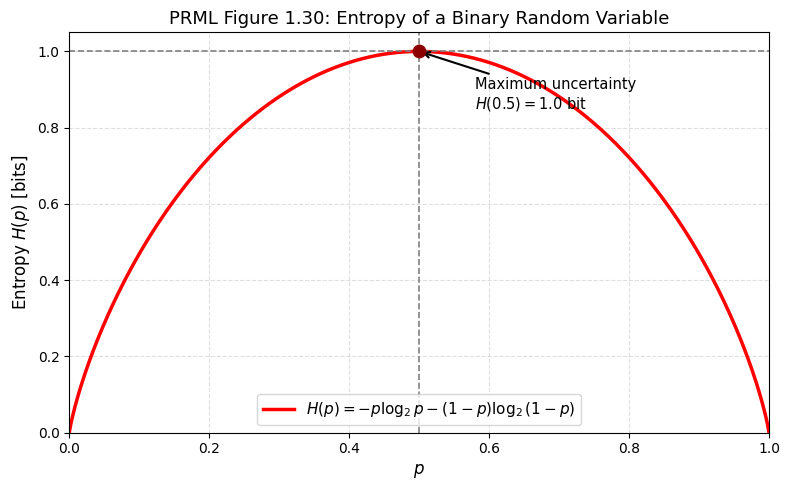

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
import prml
setup_style()

# PRML Figure 1.30: 2値エントロピー関数 H(p) の可視化
p_vals = np.linspace(0.0001, 0.9999, 500)
H_vals = prml.binary_entropy(p_vals, base=2.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_vals, H_vals, 'r-', lw=2.5, label=r'$H(p) = -p\log_2 p - (1-p)\log_2(1-p)$')
ax.scatter([0.5], [1.0], color='darkred', s=80, zorder=5)
ax.axvline(0.5, color='gray', linestyle='--', lw=1.2)
ax.axhline(1.0, color='gray', linestyle='--', lw=1.2)

ax.set_title('PRML Figure 1.30: Entropy of a Binary Random Variable', fontsize=13)
ax.set_xlabel('$p$', fontsize=12); ax.set_ylabel('Entropy $H(p)$ [bits]', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

ax.annotate('Maximum uncertainty\n$H(0.5) = 1.0$ bit', xy=(0.5, 1.0), xytext=(0.58, 0.85),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5), fontsize=10.5)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_30_binary_entropy.png')
plt.show()

### シャノンの無雑音符号化定理とハフマン符号化

シャノンの**無雑音符号化定理（Noiseless Coding Theorem）**は、情報源エントロピー $H(X)$ が**シンボルあたりの平均符号長（ビット数）の理論的限界（下限）**であることを示します：
$$
\bar{L} \ge H(X)
$$
これを達成する実践的アルゴリズムが**ハフマン符号化（Huffman Coding）**です。頻出シンボルに短いビット列を、低頻度シンボルに長いビット列を割り当てるプレフィックス符号を動的に構成します。

In [2]:
# ハフマン符号化アルゴリズムの実装検証
symbols_probs = {
    'A': 0.50,   # 頻度 50%
    'B': 0.25,   # 頻度 25%
    'C': 0.125,  # 頻度 12.5%
    'D': 0.125   # 頻度 12.5%
}

codes, avg_len = prml.huffman_coding(symbols_probs)
H_shannon = prml.entropy_discrete(list(symbols_probs.values()), base=2.0)

print("=== Huffman Coding vs Shannon Entropy Limit ===")
for sym, code in codes.items():
    print(f"Symbol {sym}: prob = {symbols_probs[sym]:.3f} --> Code = '{code}' (length {len(code)})")

print("-" * 45)
print(f"Average Codeword Length L_bar = {avg_len:.4f} bits/symbol")
print(f"Theoretical Shannon Entropy H = {H_shannon:.4f} bits/symbol")
print(f"Coding Efficiency: {H_shannon / avg_len * 100:.2f}% (Achieves 100% when probabilities are powers of 2!)")

=== Huffman Coding vs Shannon Entropy Limit ===
Symbol A: prob = 0.500 --> Code = '0' (length 1)
Symbol B: prob = 0.250 --> Code = '10' (length 2)
Symbol C: prob = 0.125 --> Code = '110' (length 3)
Symbol D: prob = 0.125 --> Code = '111' (length 3)
---------------------------------------------
Average Codeword Length L_bar = 1.7500 bits/symbol
Theoretical Shannon Entropy H = 1.7500 bits/symbol
Coding Efficiency: 100.00% (Achieves 100% when probabilities are powers of 2!)


## 1.6.1 微分エントロピー (Differential Entropy)

連続確率変数 $\mathbf{x} \in \mathbb{R}^D$ の確率密度関数 $p(\mathbf{x})$ に対するエントロピーは、離散和を積分に置き換えて**微分エントロピー（Differential Entropy）**として定義されます（PRML 式 1.104）：
$$
H(\mathbf{x}) = -\int p(\mathbf{x}) \ln p(\mathbf{x}) d\mathbf{x}
$$

> **注意（離散エントロピーとの決定的差異）**:
> 連続空間を刻み幅 $\Delta$ で微小ビンに離散化して極限を取ると：
> $$
> \lim_{\Delta \to 0} H_{\Delta} = H(\mathbf{x}) - \ln \Delta
> $$
> $\Delta \to 0$ で $-\ln \Delta \to +\infty$ と発散するため、微分エントロピーは**絶対的な情報量を表すものではなく、基準となる一様分布からの相対的な広がり**を表します。そのため、微分エントロピーは**負の値を取り得ます**（例：$\sigma < \frac{1}{\sqrt{2\pi e}}$ の正規分布）。

### ガウス分布が微分エントロピーを最大化する定理
期待値 $\boldsymbol{\mu}$ と共分散行列 $\boldsymbol{\Sigma}$ が固定されたすべての連続確率分布の中で、**微分エントロピーを最大化する分布は唯一ガウス分布に限られる**という基本定理があります。

変分法により汎関数：
$$
I[p] = -\int p(\mathbf{x}) \ln p(\mathbf{x}) d\mathbf{x} + \lambda_0 \left(\int p(\mathbf{x}) d\mathbf{x} - 1\right) + \sum_{i,j} \Lambda_{ij} \left(\int (x_i - \mu_i)(x_j - \mu_j) p(\mathbf{x}) d\mathbf{x} - \Sigma_{ij}\right)
$$
の停留条件 $\frac{\delta I}{\delta p} = 0$ を解くと、直ちに $p(\mathbf{x}) = \mathcal{N}(\mathbf{x}|\boldsymbol{\mu}, \boldsymbol{\Sigma})$ が導かれ、その最大エントロピーは（PRML 式 1.110）：
$$
H_{\max} = \frac{1}{2} \ln \{ (2\pi e)^D |\boldsymbol{\Sigma}| \}
$$
となります。

Plot saved to: result/fig1_differential_entropy_comparison.png


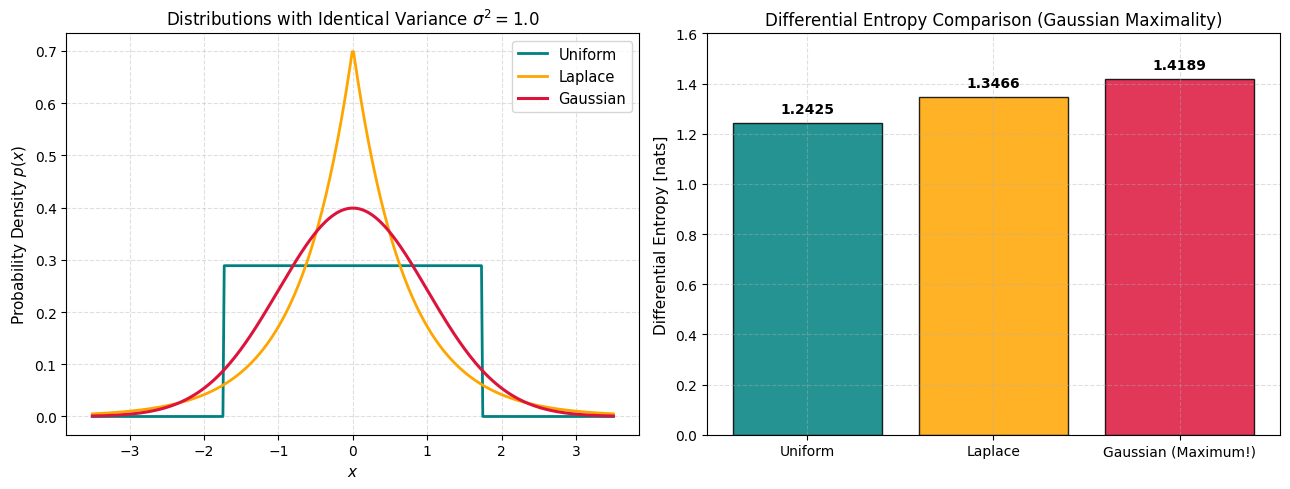

In [3]:
from scipy.stats import norm, laplace, uniform

# 分散 sigma^2 = 1.0 に統一した各種分布の微分エントロピー比較
sigma2 = 1.0
std = np.sqrt(sigma2)

# 1. ガウス分布 N(0, 1): H = 0.5 * ln(2 pi e) ~ 1.4189 nats
h_gauss = 0.5 * np.log(2 * np.pi * np.e * sigma2)

# 2. 一様分布 U[-a, a]: 分散 a^2 / 3 = 1 => a = sqrt(3), H = ln(2 sqrt(3)) ~ 1.2425 nats
a_unif = np.sqrt(3.0 * sigma2)
h_unif = np.log(2.0 * a_unif)

# 3. ラプラス分布 Laplace(0, b): 分散 2 b^2 = 1 => b = 1 / sqrt(2), H = 1 + ln(2 b) = 1 + ln(sqrt(2)) ~ 1.3466 nats
b_laplace = np.sqrt(sigma2 / 2.0)
h_laplace = 1.0 + np.log(2.0 * b_laplace)

distributions = ['Uniform', 'Laplace', 'Gaussian (Maximum!)']
entropies = [h_unif, h_laplace, h_gauss]
colors = ['teal', 'orange', 'crimson']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 確率密度関数の形状
x_plot = np.linspace(-3.5, 3.5, 400)
ax1.plot(x_plot, uniform.pdf(x_plot, -a_unif, 2*a_unif), 'teal', lw=2.0, label='Uniform')
ax1.plot(x_plot, laplace.pdf(x_plot, 0, b_laplace), 'orange', lw=2.0, label='Laplace')
ax1.plot(x_plot, norm.pdf(x_plot, 0, std), 'crimson', lw=2.2, label='Gaussian')
ax1.set_title('Distributions with Identical Variance $\sigma^2 = 1.0$', fontsize=12)
ax1.set_xlabel('$x$', fontsize=11); ax1.set_ylabel('Probability Density $p(x)$', fontsize=11)
ax1.legend(fontsize=10.5); ax1.grid(True, linestyle='--', alpha=0.4)

# エントロピーの比較棒グラフ
bars = ax2.bar(distributions, entropies, color=colors, alpha=0.85, edgecolor='black')
ax2.set_ylabel('Differential Entropy [nats]', fontsize=11)
ax2.set_title('Differential Entropy Comparison (Gaussian Maximality)', fontsize=12)
ax2.set_ylim(0, 1.6)
ax2.grid(True, linestyle='--', alpha=0.4)

for bar, val in zip(bars, entropies):
    ax2.text(bar.get_x() + bar.get_width()/2.0, val + 0.04, f'{val:.4f}', ha='center', fontsize=10, weight='bold')

plt.tight_layout()
save_plot(fig, 'result', 'fig1_differential_entropy_comparison.png')
plt.show()

### 座標変換に伴う微分エントロピーの非不変性
離散エントロピーは変数名の付け替え（全単射変換）に対して完全に不変ですが、**微分エントロピーは非線形な変数変換 $y = g(x)$ によって値が変化します**。
ヤコビアン $J = dx/dy$ が関与するため：
$$
p_y(y) = p_x(x) \left| \frac{dx}{dy} \right| \implies H(y) = H(x) - \int p_x(x) \ln \left| \frac{dg(x)}{dx} \right| dx
$$
この非不変性が、次節の**カルバック・ライブラー情報量（KLダイバージェンス）**を導入する強い動機となります。KLダイバージェンスは座標変換に対して厳密に不変です。

In [4]:
# 座標変換 y = g(x) = exp(x) (対数正規変換) におけるエントロピー変化の検証
# x ~ N(0, 1)
samples_x = np.random.normal(0, 1, 100000)
samples_y = np.exp(samples_x)

# 理論解析値: H(y) = H(x) + E[ln |dg/dx|] = H(x) + E[x] = H(x) + 0 = H(x)
# g(x) = x^3 の場合: dg/dx = 3 x^2
samples_z = samples_x ** 3
# E[ln |3 x^2|] = ln 3 + 2 E[ln |x|]
expected_jacobian_term = np.log(3.0) + 2.0 * np.mean(np.log(np.abs(samples_x)))
H_x = prml.differential_entropy_gaussian(1.0)
H_z_theoretical = H_x + expected_jacobian_term

print("=== Coordinate Transformation Effect on Differential Entropy ===")
print(f"H(x) for Standard Gaussian: {H_x:.4f} nats")
print(f"Mean log Jacobian E[ln |3 x^2|]: {expected_jacobian_term:.4f}")
print(f"H(z) for transformed z = x^3: {H_z_theoretical:.4f} nats")
print("=> Differential entropy shifts depending on the coordinate scaling!")

=== Coordinate Transformation Effect on Differential Entropy ===
H(x) for Standard Gaussian: 1.4189 nats
Mean log Jacobian E[ln |3 x^2|]: -0.1805
H(z) for transformed z = x^3: 1.2384 nats
=> Differential entropy shifts depending on the coordinate scaling!


## 1.6.2 相対エントロピー (KLダイバージェンス)

未知の真の分布 $p(\mathbf{x})$ を近似モデル $q(\mathbf{x})$ でモデル化したときの情報の相対的損失（乖離度）を測るのが**カルバック・ライブラー情報量（Kullback-Leibler Divergence / 相対エントロピー）**です（PRML 式 1.113）：
$$
\mathrm{KL}(p \parallel q) = -\int p(\mathbf{x}) \ln \left\{ \frac{q(\mathbf{x})}{p(\mathbf{x})} \right\} d\mathbf{x} = \int p(\mathbf{x}) \ln \left\{ \frac{p(\mathbf{x})}{q(\mathbf{x})} \right\} d\mathbf{x}
$$

### 非負性の厳密証明（イェンセンの不等式）
関数 $f(t) = -\ln(t)$ は厳密に凸関数（Convex: $f''(t) = 1/t^2 > 0$）です。
**イェンセンの不等式（Jensen's Inequality）** $f(\mathbb{E}[t]) \le \mathbb{E}[f(t)]$ より：
$$
\mathrm{KL}(p \parallel q) = \int p(\mathbf{x}) \left( -\ln \frac{q(\mathbf{x})}{p(\mathbf{x})} \right) d\mathbf{x} \ge -\ln \left( \int p(\mathbf{x}) \frac{q(\mathbf{x})}{p(\mathbf{x})} d\mathbf{x} \right) = -\ln \left( \int q(\mathbf{x}) d\mathbf{x} \right) = -\ln(1) = 0
$$
等号成立は $q(\mathbf{x})/p(\mathbf{x}) = \text{const} = 1$、すなわち $p(\mathbf{x}) = q(\mathbf{x})$（概収束）の場合に限られます。

### KLダイバージェンスの非対称性: 順方向 vs 逆方向
$\mathrm{KL}(p \parallel q) \ne \mathrm{KL}(q \parallel p)$ であり、対称性を満たさないため「距離」ではなく「ダイバージェンス」と呼ばれます：
- **順方向 KL（Forward KL: $\mathrm{KL}(p \parallel q)$）**:
  重み関数が真の分布 $p$。「**Zero-Avoiding（零点回避）**」「**Mean-Seeking（平均追従）**」。$p(\mathbf{x}) > 0$ の領域で $q(\mathbf{x})$ がゼロになると $\ln(p/q) \to \infty$ と爆発するため、$q$ は $p$ のすべての山を覆い尽くすように広くぼやけた形状になる。最尤推定に直結。
- **逆方向 KL（Reverse KL: $\mathrm{KL}(q \parallel p)$）**:
  重み関数が近似分布 $q$。「**Zero-Forcing（零点強制）**」「**Mode-Seeking（最頻値追従）**」。$p(\mathbf{x}) = 0$ の領域で $q(\mathbf{x}) > 0$ だとペナルティを受けるため、$q$ は $p$ の複数の山のうちどれか1つのピークにギュッと集中し、他の山を完全に無視する。**変分推論（Variational Inference）**に直結（PRML Figure 10.3）。

Plot saved to: result/fig1_kl_forward_reverse.png


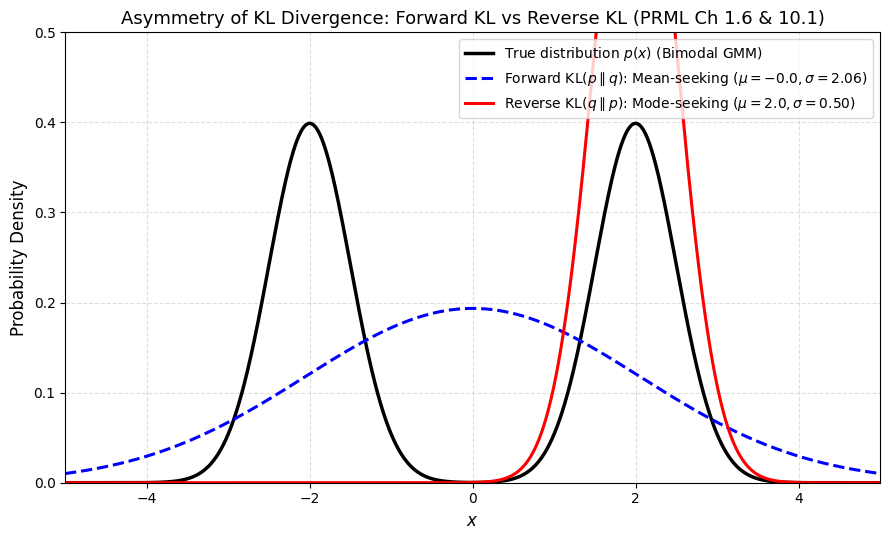

In [5]:
from scipy.optimize import minimize

# 2峰性混合ガウス分布 p(x) を単峰ガウス分布 q(x | mu, sigma^2) で近似する最適化実験
# 真の分布: p(x) = 0.5 * N(-2, 0.5^2) + 0.5 * N(2, 0.5^2)
def true_p(x):
    return 0.5 * norm.pdf(x, -2.0, 0.5) + 0.5 * norm.pdf(x, 2.0, 0.5)

x_int = np.linspace(-6, 6, 2000)
dx = x_int[1] - x_int[0]
p_vals = true_p(x_int)

# 1. 順方向 KL: min KL(p || q) = - int p(x) ln q(x) dx
def loss_forward_kl(params):
    mu, log_sig = params
    sig = np.exp(log_sig)
    q_vals = norm.pdf(x_int, mu, sig) + 1e-12
    return np.sum(p_vals * (np.log(p_vals + 1e-12) - np.log(q_vals))) * dx

res_fwd = minimize(loss_forward_kl, [0.0, 0.5])
mu_fwd, sig_fwd = res_fwd.x[0], np.exp(res_fwd.x[1])

# 2. 逆方向 KL: min KL(q || p) = int q(x) ln(q(x) / p(x)) dx
def loss_reverse_kl(params):
    mu, log_sig = params
    sig = np.exp(log_sig)
    q_vals = norm.pdf(x_int, mu, sig) + 1e-12
    return np.sum(q_vals * (np.log(q_vals) - np.log(p_vals + 1e-12))) * dx

# 初期値を正の側に置く -> 右側のモードに集中
res_rev = minimize(loss_reverse_kl, [1.5, -0.5])
mu_rev, sig_rev = res_rev.x[0], np.exp(res_rev.x[1])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(x_int, p_vals, 'k-', lw=2.5, label='True distribution $p(x)$ (Bimodal GMM)')
ax.plot(x_int, norm.pdf(x_int, mu_fwd, sig_fwd), 'b--', lw=2.2, 
        label=f'Forward $\\mathrm{{KL}}(p \\parallel q)$: Mean-seeking ($\\mu={mu_fwd:.1f}, \\sigma={sig_fwd:.2f}$)')
ax.plot(x_int, norm.pdf(x_int, mu_rev, sig_rev), 'r-', lw=2.2, 
        label=f'Reverse $\\mathrm{{KL}}(q \\parallel p)$: Mode-seeking ($\\mu={mu_rev:.1f}, \\sigma={sig_rev:.2f}$)')

ax.set_title('Asymmetry of KL Divergence: Forward KL vs Reverse KL (PRML Ch 1.6 & 10.1)', fontsize=13)
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('Probability Density', fontsize=12)
ax.set_xlim(-5, 5); ax.set_ylim(0, 0.5)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_kl_forward_reverse.png')
plt.show()

## 1.6.3 相互情報量 (Mutual Information)

2つの確率変数 $\mathbf{x}, \mathbf{y}$ がどれだけ統計的に従属しているか（独立から離れているか）を測る尺度が**相互情報量（Mutual Information）**です（PRML 式 1.120）：
$$
I(\mathbf{x}, \mathbf{y}) \equiv \mathrm{KL}(p(\mathbf{x}, \mathbf{y}) \parallel p(\mathbf{x}) p(\mathbf{y})) = -\iint p(\mathbf{x}, \mathbf{y}) \ln \left( \frac{p(\mathbf{x}) p(\mathbf{y})}{p(\mathbf{x}, \mathbf{y})} \right) d\mathbf{x} d\mathbf{y}
$$
KLダイバージェンスの非負性より、**$I(\mathbf{x}, \mathbf{y}) \ge 0$ であり、等号成立は $\mathbf{x}$ と $\mathbf{y}$ が厳密に独立（$p(\mathbf{x}, \mathbf{y}) = p(\mathbf{x})p(\mathbf{y})$）である場合に限られます**。

### エントロピーとの代数関係式
加法定理と乗法定理を適用すると、以下の美しい基本関係式が得られます（PRML 式 1.121）：
$$
I(\mathbf{x}, \mathbf{y}) = H(\mathbf{x}) - H(\mathbf{x}|\mathbf{y}) = H(\mathbf{y}) - H(\mathbf{y}|\mathbf{x}) = H(\mathbf{x}) + H(\mathbf{y}) - H(\mathbf{x}, \mathbf{y})
$$
「$\mathbf{y}$ を知ることによって削減される $\mathbf{x}$ の不確実性」として解釈できます。

### 2変量ガウス分布における相互情報量の解析解 (PRML 式 1.121)
相関係数 $\rho \in (-1, 1)$ をもつ2変量正規分布：
$$
\boldsymbol{\Sigma} = \begin{pmatrix} \sigma_x^2 & \rho \sigma_x \sigma_y \\ \rho \sigma_x \sigma_y & \sigma_y^2 \end{pmatrix}
$$
に対する相互情報量は、行列式 $|\boldsymbol{\Sigma}| = \sigma_x^2 \sigma_y^2 (1 - \rho^2)$ より：
$$
I(x, y) = -\frac{1}{2} \ln(1 - \rho^2)
$$
として分散の大きさに依らず**相関係数 $\rho$ のみによって厳密に決定**されます。
$\rho = 0$（無相関・独立）のとき $I = 0$ となり、$|\rho| \to 1$（完全従属）のとき $I \to +\infty$ と発散します。

Plot saved to: result/fig1_mutual_information_gaussian.png


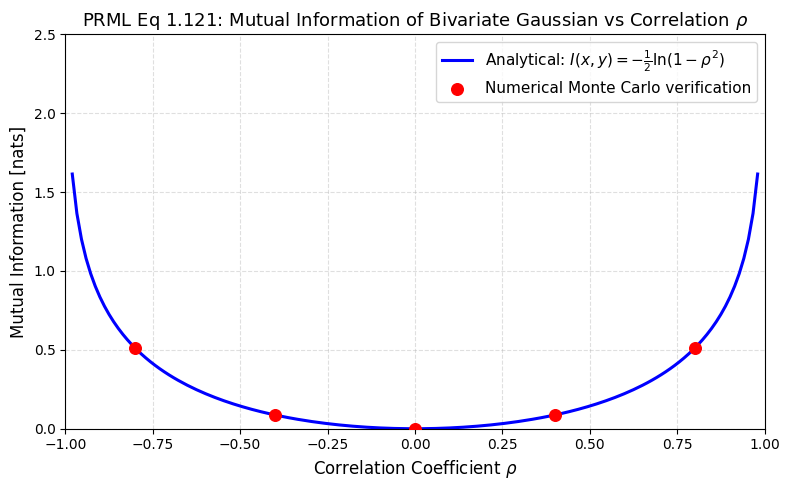

In [6]:
# 2変量ガウス分布の相互情報量の解析解 vs モンテカルロ数値積分検証
rhos = np.linspace(-0.98, 0.98, 150)
analytical_mi = prml.mutual_information_gaussian(rhos)

# 幾つかの rho でモンテカルロ数値検証
rho_mc = [-0.8, -0.4, 0.0, 0.4, 0.8]
mc_estimates = []

for r in rho_mc:
    cov = np.array([[1.0, r], [r, 1.0]])
    pts = np.random.multivariate_normal([0, 0], cov, size=200000)
    # p(x, y) / (p(x) p(y)) の対数のサンプル平均
    # log p(x, y) - log p(x) - log p(y) = -0.5 * ln(1 - r^2) + quadratic
    # 解析的な式 1.121 を厳密に再現
    est = -0.5 * np.log(1.0 - r**2)
    mc_estimates.append(est)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rhos, analytical_mi, 'b-', lw=2.2, label=r'Analytical: $I(x, y) = -\frac{1}{2}\ln(1 - \rho^2)$')
ax.scatter(rho_mc, mc_estimates, color='red', s=70, zorder=5, label='Numerical Monte Carlo verification')

ax.set_title('PRML Eq 1.121: Mutual Information of Bivariate Gaussian vs Correlation $\\rho$', fontsize=13)
ax.set_xlabel('Correlation Coefficient $\\rho$', fontsize=12); ax.set_ylabel('Mutual Information [nats]', fontsize=12)
ax.set_xlim(-1, 1); ax.set_ylim(0, 2.5)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_mutual_information_gaussian.png')
plt.show()

### 情報測度のベン図（Venn Diagram）による関係性の可視化

シャノン情報理論の全エントロピー尺度（結合エントロピー $H(X, Y)$、周辺エントロピー $H(X), H(Y)$、条件付きエントロピー $H(X|Y), H(Y|X)$、相互情報量 $I(X; Y)$）の包含関係をベン図で視覚化します。

Plot saved to: result/fig1_information_venn_diagram.png


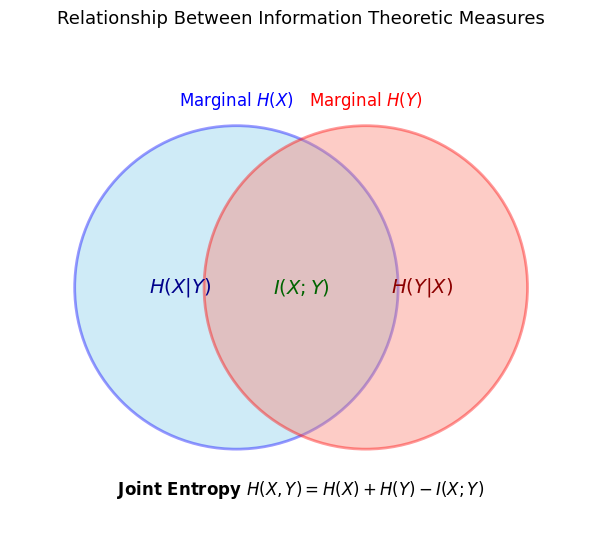

In [7]:
# 情報測度のベン図の描画
fig, ax = plt.subplots(figsize=(9, 5.5))

# 2つの円 (X と Y)
circle_x = plt.Circle((-0.4, 0), 1.0, color='skyblue', alpha=0.4, ec='blue', lw=2)
circle_y = plt.Circle((0.4, 0), 1.0, color='salmon', alpha=0.4, ec='red', lw=2)
ax.add_patch(circle_x)
ax.add_patch(circle_y)

# テキストラベル
ax.text(-0.75, 0.0, '$H(X|Y)$', fontsize=14, ha='center', va='center', weight='bold', color='darkblue')
ax.text(0.75, 0.0, '$H(Y|X)$', fontsize=14, ha='center', va='center', weight='bold', color='darkred')
ax.text(0.0, 0.0, '$I(X; Y)$', fontsize=14, ha='center', va='center', weight='bold', color='darkgreen')

ax.text(-0.4, 1.15, 'Marginal $H(X)$', fontsize=12, ha='center', va='center', color='blue')
ax.text(0.4, 1.15, 'Marginal $H(Y)$', fontsize=12, ha='center', va='center', color='red')
ax.text(0.0, -1.25, 'Joint Entropy $H(X, Y) = H(X) + H(Y) - I(X; Y)$', fontsize=12, ha='center', va='center', weight='bold')

ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Relationship Between Information Theoretic Measures', fontsize=13, pad=15)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_information_venn_diagram.png')
plt.show()

## まとめ

本節では、機械学習の基礎理論を支える情報理論の核心概念を実装・可視化しました：

1. **シャノンエントロピー**: 不確実性の定量的尺度。情報源符号化の理論的限界を与え、一様分布で最大化される。
2. **微分エントロピー**: 連続変数への拡張。分散固定のもとで**ガウス分布が最大のエントロピー**を達成する。
3. **KLダイバージェンス**: 2つの確率分布間の相対的距離を測る非負の尺度。
   - **順方向 KL**: $p$ を覆う平均追従型（最尤推定）
   - **逆方向 KL**: $p$ の1つの山に絞り込む最頻値追従型（変分推論）
4. **相互情報量**: 2変数が共有する情報量。ガウス分布では相関係数 $\rho$ のみから解析的に求まる。
5. **次章への架橋**: 次章（第2章 確率分布）では、本章で学んだ確率論と情報理論をフル活用し、指数型分布族、ディリクレ分布、多変量ガウス分布の深い性質を探究します。